In [ ]:
import os
from pathlib import Path
import matplotlib.pyplot as plt

_TREBL_FIG_DIR = Path.cwd() / 'saved_figures'
_TREBL_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _trebl_notebook_stem():
    session_path = os.environ.get('JPY_SESSION_NAME', '')
    if session_path:
        raw_stem = Path(session_path).stem or 'notebook'
        safe_stem = ''.join(ch if (ch.isalnum() or ch in {'_', '-'}) else '_' for ch in raw_stem)
        return safe_stem.strip('_') or 'notebook'
    return 'notebook'


# Reset counter and stem every time this cell runs so re-running replaces existing images
if hasattr(plt, '_trebl_autosave_original_show'):
    plt.show = plt._trebl_autosave_original_show

plt._trebl_autosave_original_show = plt.show
plt._trebl_autosave_counter = 1
plt._trebl_notebook_stem = _trebl_notebook_stem()


def _trebl_autosave_show(*args, **kwargs):
    for fig_num in plt.get_fignums():
        fig = plt.figure(fig_num)
        stem = f"{plt._trebl_notebook_stem}_figure_{plt._trebl_autosave_counter:04d}"
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.png', dpi=300, bbox_inches='tight')
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.pdf', dpi=300, bbox_inches='tight')
        plt._trebl_autosave_counter += 1
    return plt._trebl_autosave_original_show(*args, **kwargs)


plt.show = _trebl_autosave_show


In [1]:
import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import seaborn as sns

In [2]:
%load_ext autoreload
%autoreload 2
import os

os.chdir("../../../notebooks/ChopTFs/pipeline/")
import time_normalization_helpers
import speed_plotting_helpers

In [3]:
activities = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/activities_to_fit.csv", index_col = 0)
activities

,ADseq,time,activity,ci_low,ci_hi,n_barcodes,class,error,activity_norm,ci_low_norm,ci_hi_norm
10,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0,0.603252,0.489177,0.723339,2.0,ns,0.059735,0.000000,-0.114075,0.120087
11,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,5,0.849635,0.104610,1.406962,2.0,ns,0.332233,0.246383,-0.498641,0.803710
12,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,10,1.384974,0.885289,1.855112,2.0,activator,0.247404,0.781723,0.282038,1.251861
13,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,15,1.590645,0.729068,2.033041,2.0,ns,0.332646,0.987393,0.125816,1.429790
14,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,30,1.813740,1.245708,2.308080,2.0,activator,0.271013,1.210488,0.642456,1.704829
...,...,...,...,...,...,...,...,...,...,...,...
55384,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,0,0.040089,NaN,NaN,NaN,ns,NaN,0.000000,NaN,NaN
55385,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,5,0.490969,NaN,NaN,NaN,ns,NaN,0.450881,NaN,NaN
55386,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,10,1.303383,NaN,NaN,NaN,activator,NaN,1.263294,NaN,NaN
55387,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,15,1.037466,NaN,NaN,NaN,activator,NaN,0.997377,NaN,NaN


In [14]:
import numpy as np
from scipy.optimize import curve_fit

def make_feasible(p0, lb, ub):
    eps = 1e-6
    return np.minimum(np.maximum(p0, np.array(lb) + eps), np.array(ub) - eps)

def hill(t, Vmax, K, n):
    return Vmax * (t**n) / (K**n + t**n)

def weighted_r2(y, y_pred, sigma=None):
    if sigma is None:
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        return 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    w = 1 / np.clip(sigma, 1e-6, None)**2
    y_wmean = np.sum(w * y) / np.sum(w)
    ss_res = np.sum(w * (y - y_pred)**2)
    ss_tot = np.sum(w * (y - y_wmean)**2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

def compute_t_half_obs(t, popt, obs_max):
    t_grid = np.linspace(np.min(t), np.max(t), 500)
    y_fit = hill(t_grid, *popt)
    target = 0.5 * obs_max
    idx = np.argmin(np.abs(y_fit - target))
    return t_grid[idx]

def fit_hill(df):
    df = df.sort_values("time")
    t = df["time"].values.astype(float)
    y = df["activity_norm"].values.astype(float)
    raw_sigma = df["error"].values.astype(float)

    # drop rows where y is not finite; keep rows where sigma is NaN (handled below)
    valid = np.isfinite(y)
    t = t[valid]
    y = y[valid]
    raw_sigma = raw_sigma[valid]

    # if any sigma values are finite, filter to only those rows; otherwise go unweighted
    if np.any(np.isfinite(raw_sigma)):
        finite_sigma = np.isfinite(raw_sigma)
        t = t[finite_sigma]
        y = y[finite_sigma]
        raw_sigma = raw_sigma[finite_sigma]
        sigma = np.clip(raw_sigma, 1e-6, None)
    else:
        sigma = None

    lb = [0, 0, 0.5]
    ub = [np.max(y) * 3, np.max(t) * 10 if np.max(t) > 0 else 10, 5]
    Vmax0 = np.max(y)
    K0 = np.median(t[t > 0]) if np.any(t > 0) else 1.0
    n0 = 2.0
    p0 = make_feasible([Vmax0, K0, n0], lb, ub)

    try:
        popt, pcov = curve_fit(
            hill, t, y,
            p0=p0,
            sigma=sigma,
            absolute_sigma=True if sigma is not None else False,
            bounds=(lb, ub)
        )
        y_pred = hill(t, *popt)
        r2 = weighted_r2(y, y_pred, sigma)
        t_grid = np.linspace(np.min(t), np.max(t), 500)
        obs_max = np.max(hill(t_grid, *popt))
        t_half_obs = compute_t_half_obs(t, popt, obs_max)
        return {
            "Vmax": popt[0], "K_fit": popt[1], "n": popt[2],
            "r2": r2, "obs_max": obs_max, "t_half_obs": t_half_obs,
            "success": True
        }
    except (RuntimeError, ValueError):
        return {
            "Vmax": np.nan, "K_fit": np.nan, "n": np.nan,
            "r2": np.nan, "obs_max": np.nan, "t_half_obs": np.nan,
            "success": False
        }

In [15]:
results = []

for ad, subdf in tqdm.tqdm(activities.groupby("ADseq")):
    fit = fit_hill(subdf)
    fit["ADseq"] = ad
    results.append(fit)

results_df = pd.DataFrame(results)
results_df

100%|██████████| 4713/4713 [00:26<00:00, 180.51it/s]


,Vmax,K_fit,n,r2,obs_max,t_half_obs,success,ADseq
0,10.545748,103.468897,0.500000,0.990855,3.691018,4.629259,True,AAAQHVPAADGQWLALFPHPSSIDFDFNSFHQSFSSPPPH
1,1.244459,8.346715,2.599885,0.999485,1.201293,8.116232,True,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS
2,2.539518,5.614880,1.208565,0.996085,2.243477,4.629259,True,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS
3,2.179818,4.715282,1.350423,0.994071,2.014279,4.208417,True,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN
4,2.729173,4.913649,1.383259,0.999732,2.522634,4.388778,True,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI
...,...,...,...,...,...,...,...,...
4708,3.612285,5.355609,1.439216,0.999707,3.333116,4.809619,True,YTNLTTPGTSYIDSPLYIADSTDTSPLFATDGLGADADSW
4709,4.540302,5.384550,0.787236,0.999030,3.607225,3.186373,True,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM
4710,2.908462,6.137081,1.171194,0.999317,2.516177,4.869739,True,YTTASSSSFSSASANILPRDFSVFTTDSQSSWLPSSSPSL
4711,3.935261,63.553550,0.794020,0.999991,1.397985,9.198397,True,YVEGLRWVTWGQMGHVELSPVSRFTATIPSHDFQSFVTDH


In [16]:
ok = results_df[results_df["r2"] >= 0.7]
print(f"Keeping {len(ok)} / {len(results_df)} sequences ({100*len(ok)/len(results_df):.1f}%)")

Keeping 4610 / 4713 sequences (97.8%)


In [17]:
ok.to_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/hill_fit_baseline_norm.csv")

In [18]:
not_ok = results_df[results_df["r2"] < 0.7]
not_ok

,Vmax,K_fit,n,r2,obs_max,t_half_obs,success,ADseq
80,6.484230,202.208975,0.500000,5.338078e-01,1.803074,5.290581,True,AFSLEEFTAFGGGASTTAYSSPAIPGYDVNASSSSSSTTN
140,2.743320,37.395666,3.238164,5.753092e-01,0.902042,22.605210,True,ALAAQLLTGHAAEPNVAYHSTFGELSSTGDGGLFGMDEHF
154,2.896716,34.491710,5.000000,4.368244e-01,0.962703,25.010020,True,ALQNQRVAAIIQSTGHSINTSALTNRFTPQQSSIQQFYAS
209,7.221714,171.076599,0.589991,4.132441e-01,1.903949,7.034068,True,APNSTAFTALTSPSPYESPDFDVYDVSPHFSTTDFDSGGP
256,0.905122,6.222411,5.000000,4.404706e-01,0.904775,6.192385,True,ARNTLAARKSRQRKMQKMEELEDQIAKLEAERDHWKNIAL
...,...,...,...,...,...,...,...,...
4247,1.135997,0.015932,4.465101,-1.947018e-10,1.135997,5.000000,True,TQDGAWYSLFPDAAPDTEESSVSPPNPTLPVQGSPLIGNG
4263,3.511710,193.185725,0.500000,3.444339e-01,0.992675,5.230461,True,TRRQRSSPLAPIVVKDDDPVSMKRARNTEAARRSRAKKMK
4314,2.436589,78.240546,0.864115,5.385747e-01,0.740717,10.701403,True,TSTSIPTSFTATFPSLDNQFSNTSGSSNSRTVNGTTRIIS
4578,0.692270,5.721285,5.000000,4.210132e-01,0.692095,5.711423,True,VSSEQPLLRFSRSPTATIPPQDFTVFTTDSQQSTWLPSRA


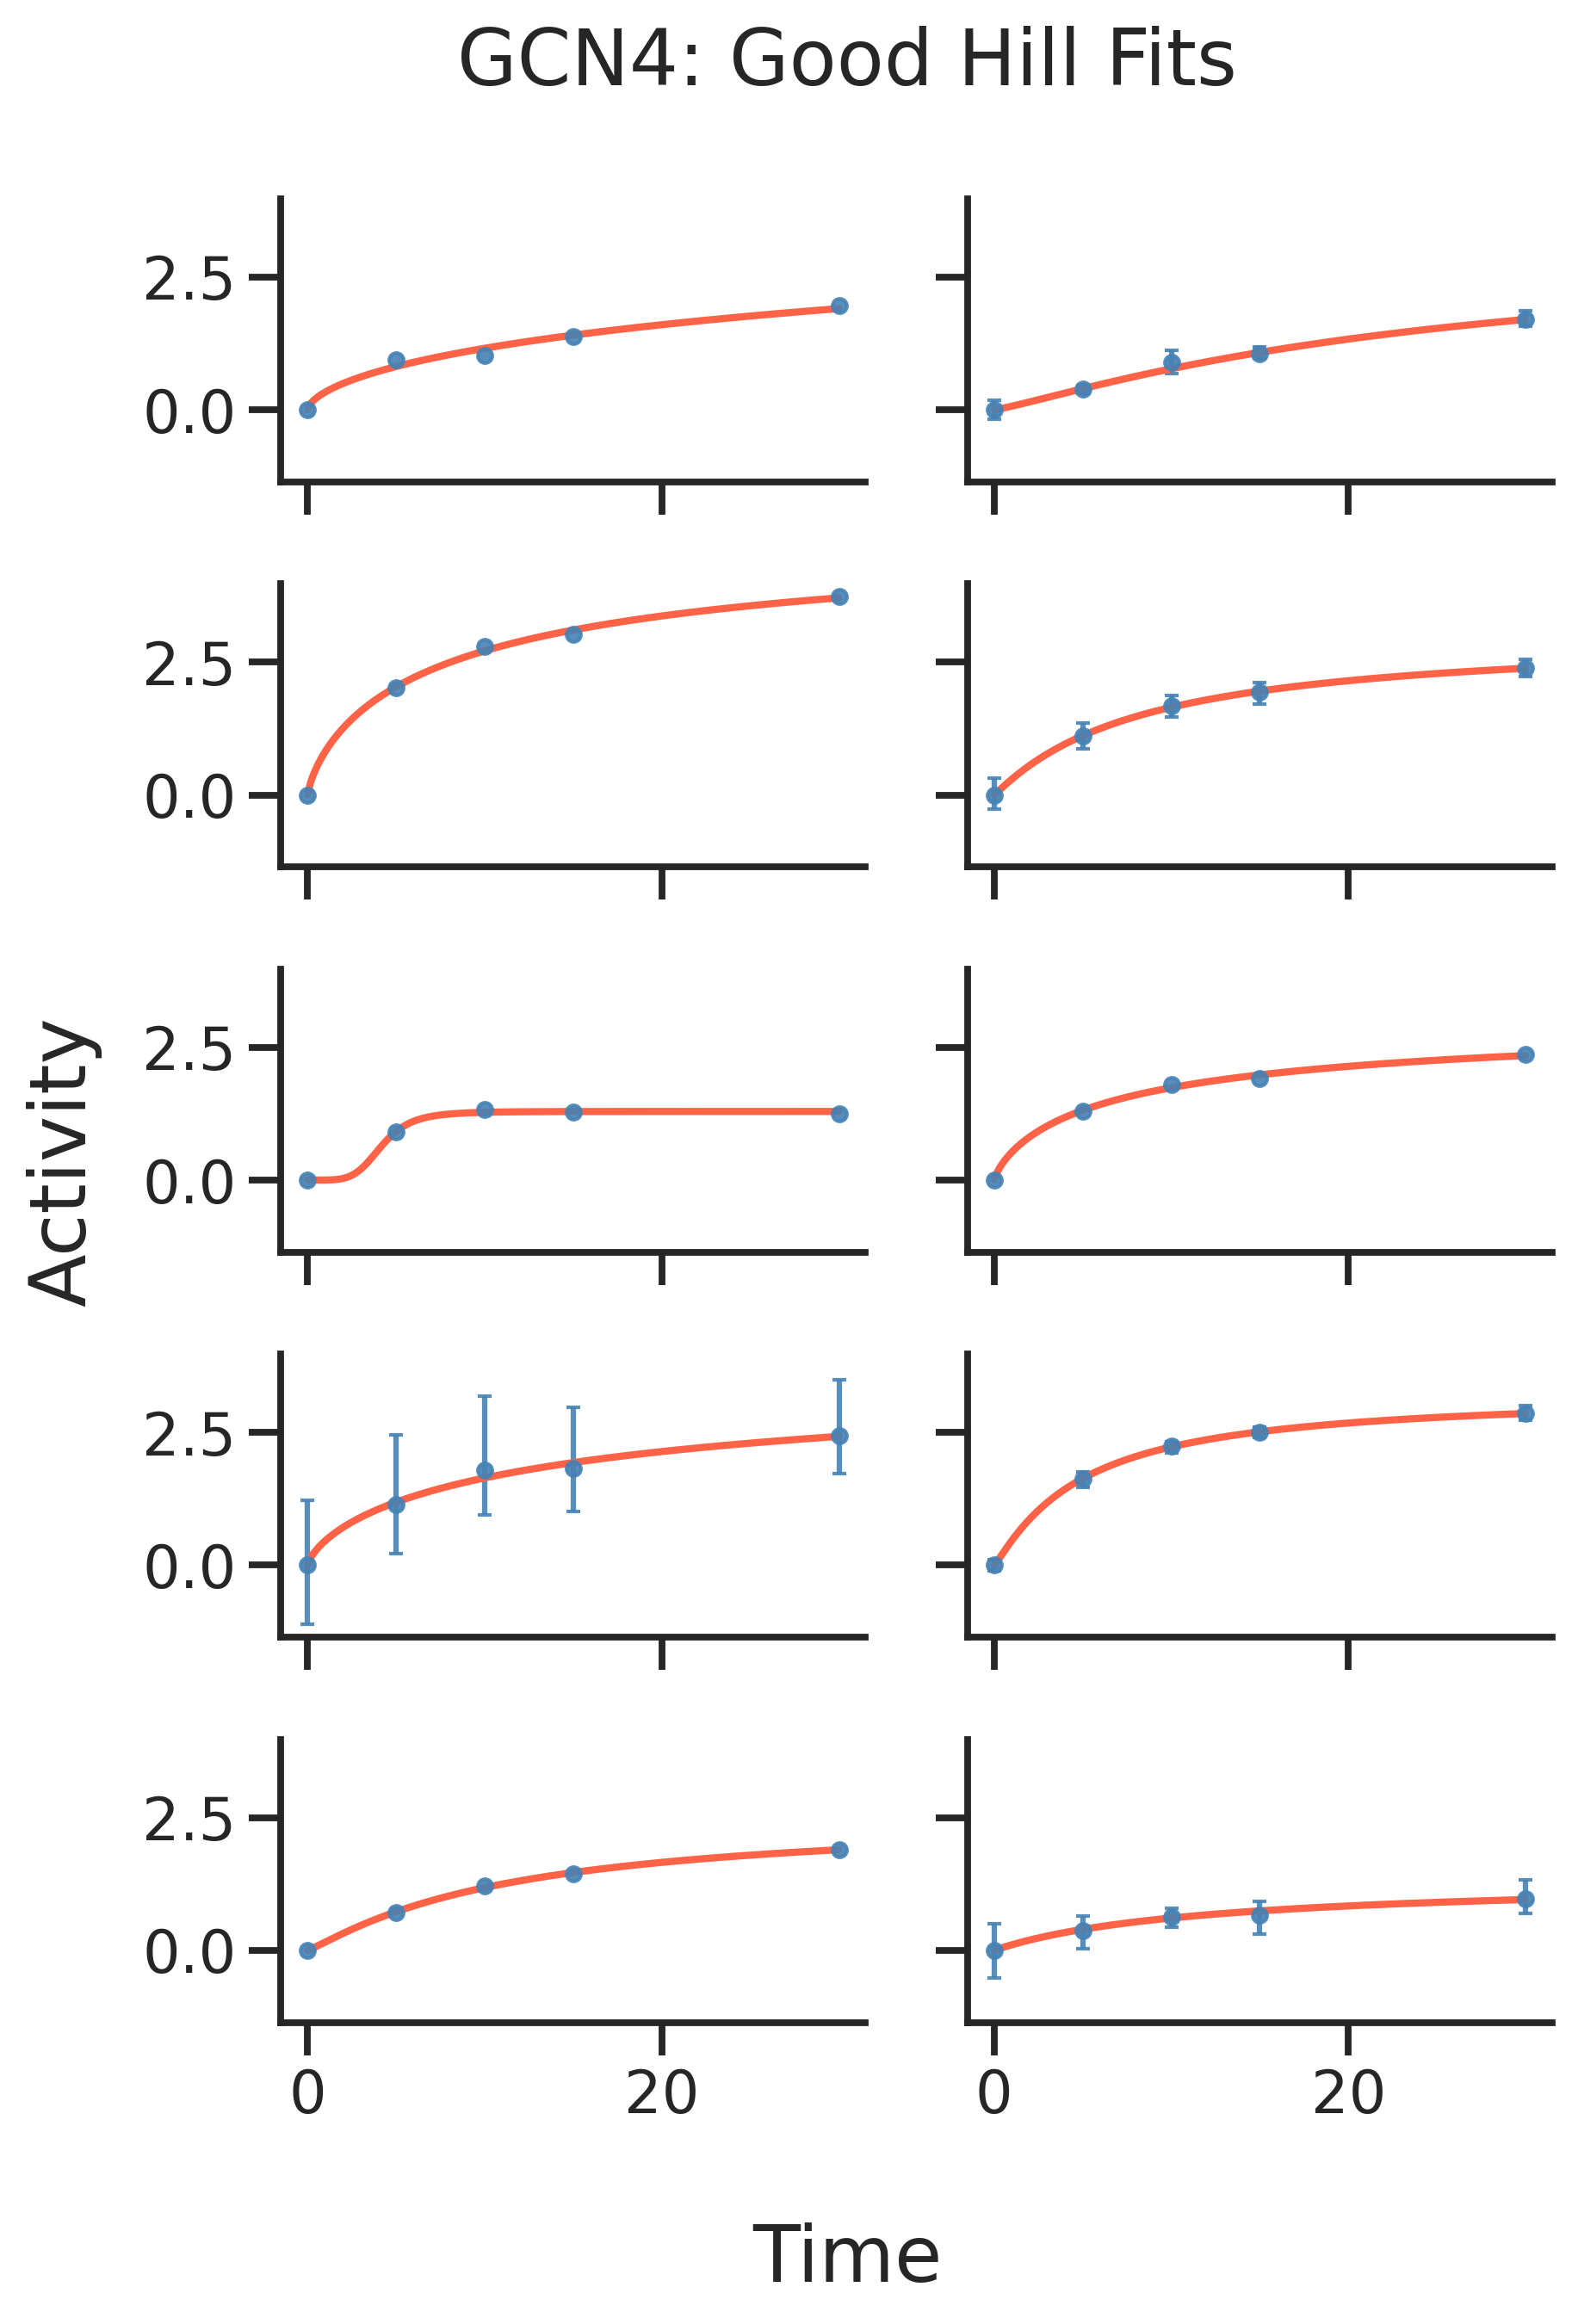

In [19]:
for df, title in zip([ok], ["Good"]):
    sample_adseqs = df.sample(16, random_state=44)['ADseq'].values

    speed_plotting_helpers.plot_model_fits(
        activities=activities,
        fit_results=results_df,
        sample_adseqs=sample_adseqs,
        model_fn=hill,
        model_params=['Vmax', 'K_fit', 'n'],
        y_col='activity_norm',
        ci_low_col='ci_low_norm',
        ci_hi_col='ci_hi_norm',
        title=f'GCN4: {title} Hill Fits',
    )

Pearson r = -0.576, p = 0
Spearman rho = -0.667, p = 0


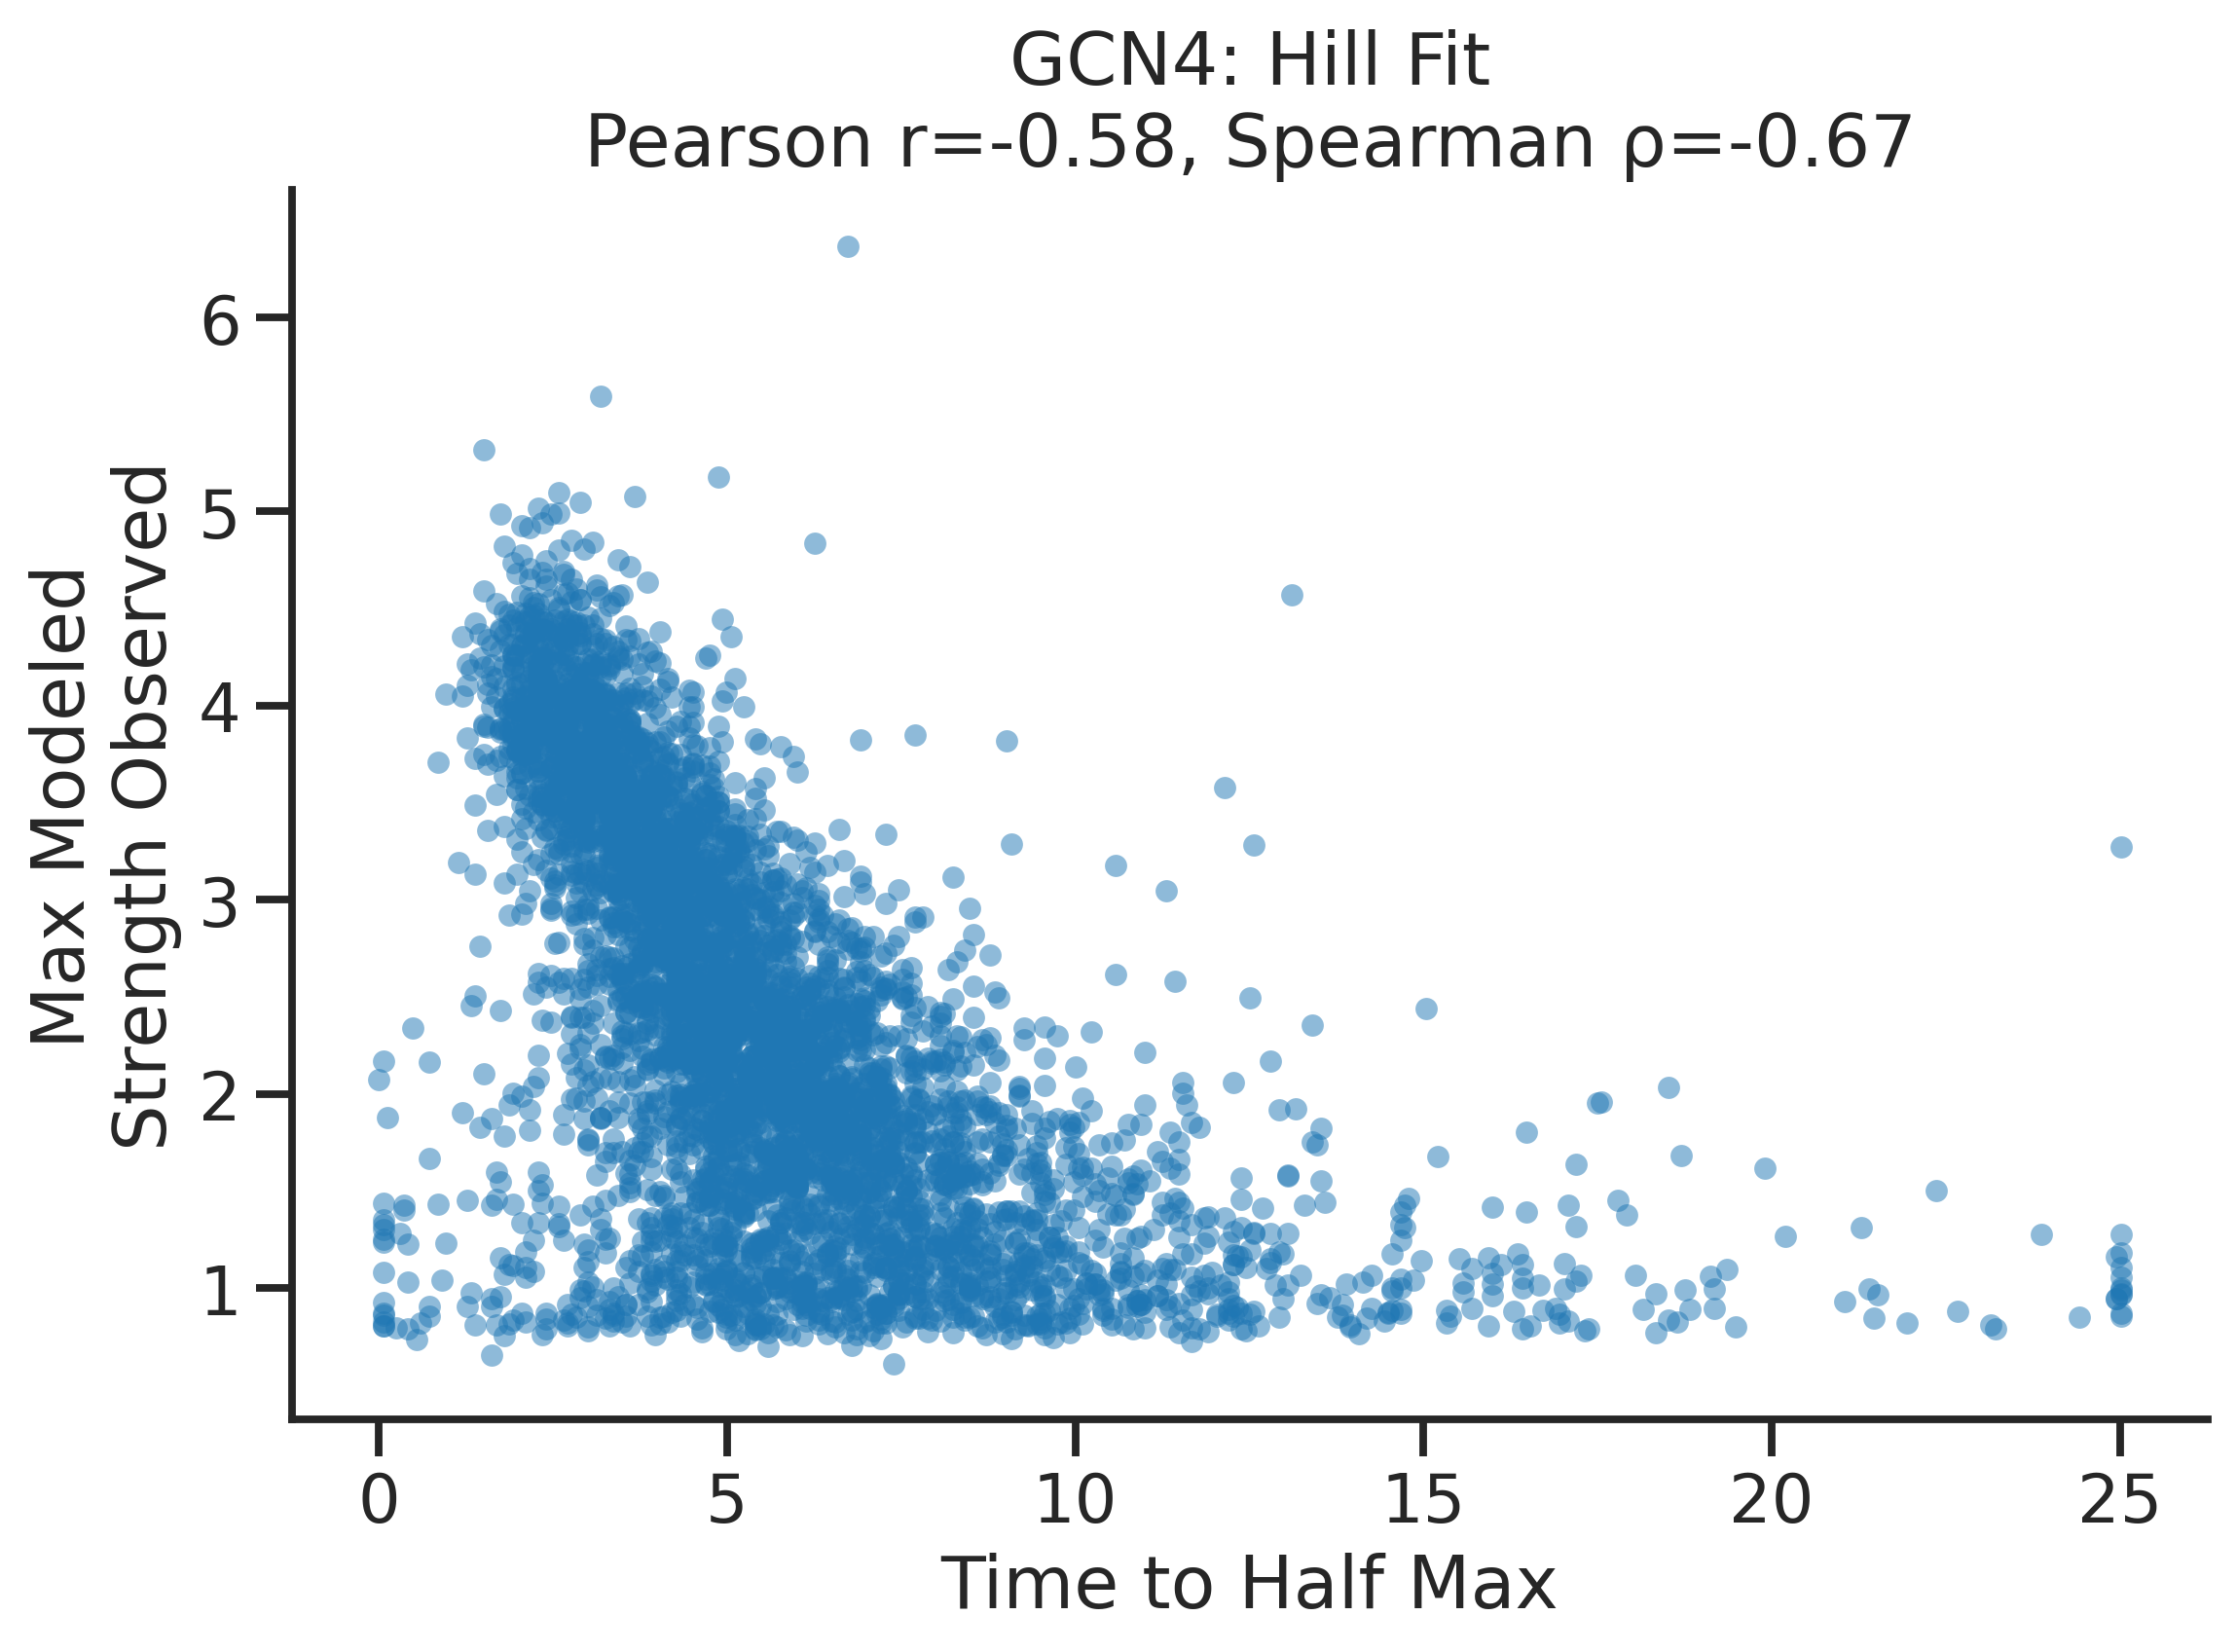

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['t_half_obs'], ok ['obs_max'])
spearman_corr, spearman_p = spearmanr(ok['t_half_obs'], ok ['obs_max'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['t_half_obs'], ok['obs_max'],
    alpha=0.5,
    s=30,
    linewidths=0
)


ax.set_xlabel('Time to Half Max')
ax.set_ylabel('Max Modeled\nStrength Observed')
ax.set_title(f'GCN4: Hill Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

# ax.set_xlim(0,31)
# ax.set_ylim(0,2.5)

plt.tight_layout()
sns.despine()
plt.show()

In [21]:
# --- filter valid sequences ---
filtered = ok[
    (ok['t_half_obs'] >= 0) &
    (ok['obs_max'] >= 0) 
].copy()

# --- 1. Similar strength (A), different speed (k) ---
A_target = filtered['obs_max'].median()
A_tol = filtered['obs_max'].std() * 0.5

similar_A = filtered[(filtered['obs_max'] >= A_target - A_tol) &
                     (filtered['obs_max'] <= A_target + A_tol)].copy()
similar_A_sorted = similar_A.sort_values('t_half_obs')

if len(similar_A_sorted) >= 2:
    seq_simA_diffk = similar_A_sorted.iloc[[0,-1]]  # pick lowest and highest speed
else:
    seq_simA_diffk = similar_A_sorted.copy()  # fallback if not enough sequences

# --- 2. Similar speed (k), different strength (A) ---
k_target = filtered['t_half_obs'].median()
k_tol = filtered['t_half_obs'].std() * 0.2

similar_k = filtered[(filtered['t_half_obs'] >= k_target - k_tol) &
                     (filtered['t_half_obs'] <= k_target + k_tol)].copy()
similar_k_sorted = similar_k.sort_values('obs_max')

if len(similar_k_sorted) >= 2:
    seq_simk_diffA = similar_k_sorted.iloc[[0,-1]]  # pick lowest and highest strength
else:
    seq_simk_diffA = similar_k_sorted.copy()  # fallback

# --- combine sequences to plot ---
to_plot = pd.concat([seq_simA_diffk, seq_simk_diffA]).reset_index(drop=True)
to_plot

,Vmax,K_fit,n,r2,obs_max,t_half_obs,success,ADseq
0,2.074997,0.000004,4.999428,0.955085,2.074997,0.000000,True,NSVAEQMPAQTVSPKDLMMDSSAPPSTSFTDMSTPSFESP
1,6.400350,45.078888,1.876229,0.719043,2.033849,18.517034,True,THLQQRQTRPPVPPFSQSTGQIPQTPNMAMQDMDLFDEFT
2,0.700716,5.566315,5.000000,0.833005,0.700562,5.591182,True,SAATTSASSPDLISTVATSVAASTSHKRPFGEVDSVGTAT
3,7.693132,11.786339,0.771632,0.979868,5.175982,4.869739,True,SPFITDSFEASPMFQGDSCFPTGTDTWYSLFPEEESRTVM


Pearson r = -0.576, p = 0
Spearman rho = -0.667, p = 0


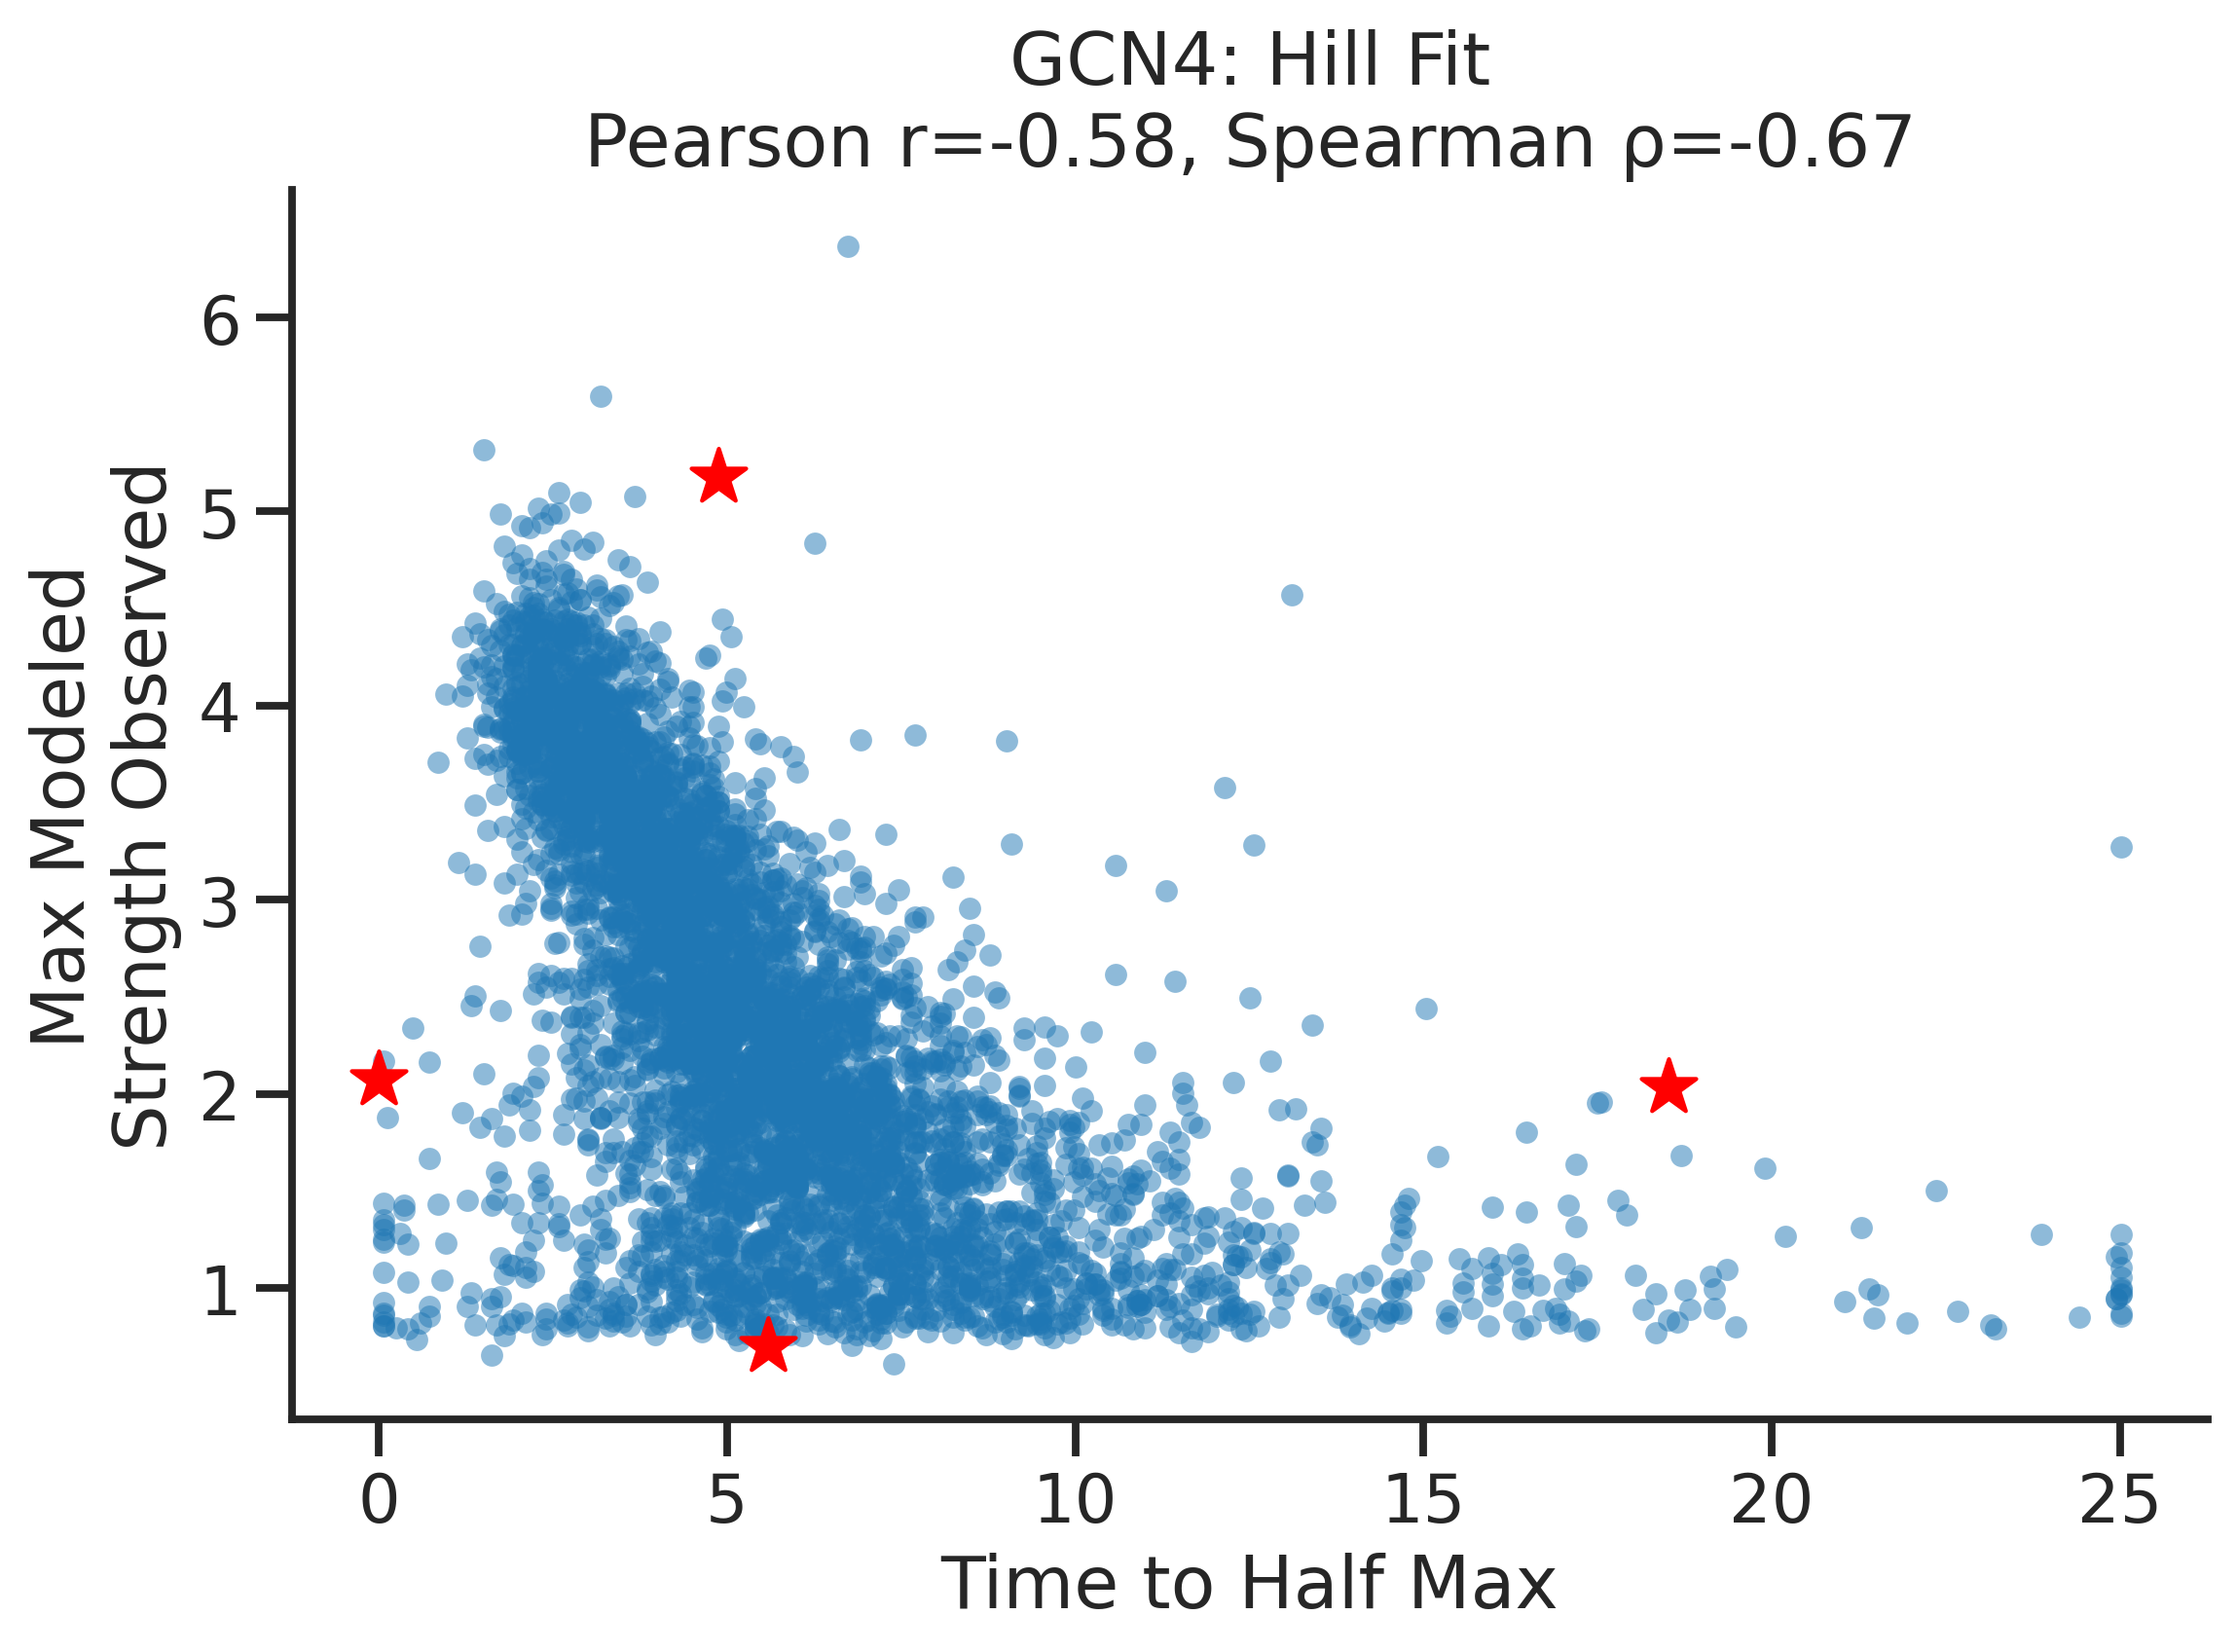

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['t_half_obs'], ok ['obs_max'])
spearman_corr, spearman_p = spearmanr(ok['t_half_obs'], ok ['obs_max'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['t_half_obs'], ok['obs_max'],
    alpha=0.5,
    s=30,
    linewidths=0
)

ax.scatter(
    to_plot['t_half_obs'], to_plot['obs_max'],
    alpha=1,
    s=200,
    linewidths=1,
    edgecolors='red',
    color='red',
    marker = '*'
)

ax.set_xlabel('Time to Half Max')
ax.set_ylabel('Max Modeled\nStrength Observed')
ax.set_title(f'GCN4: Hill Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

# ax.set_xlim(0,31)
# ax.set_ylim(0,2.5)

plt.tight_layout()
sns.despine()
plt.show()

ValueError: Axis limits cannot be NaN or Inf

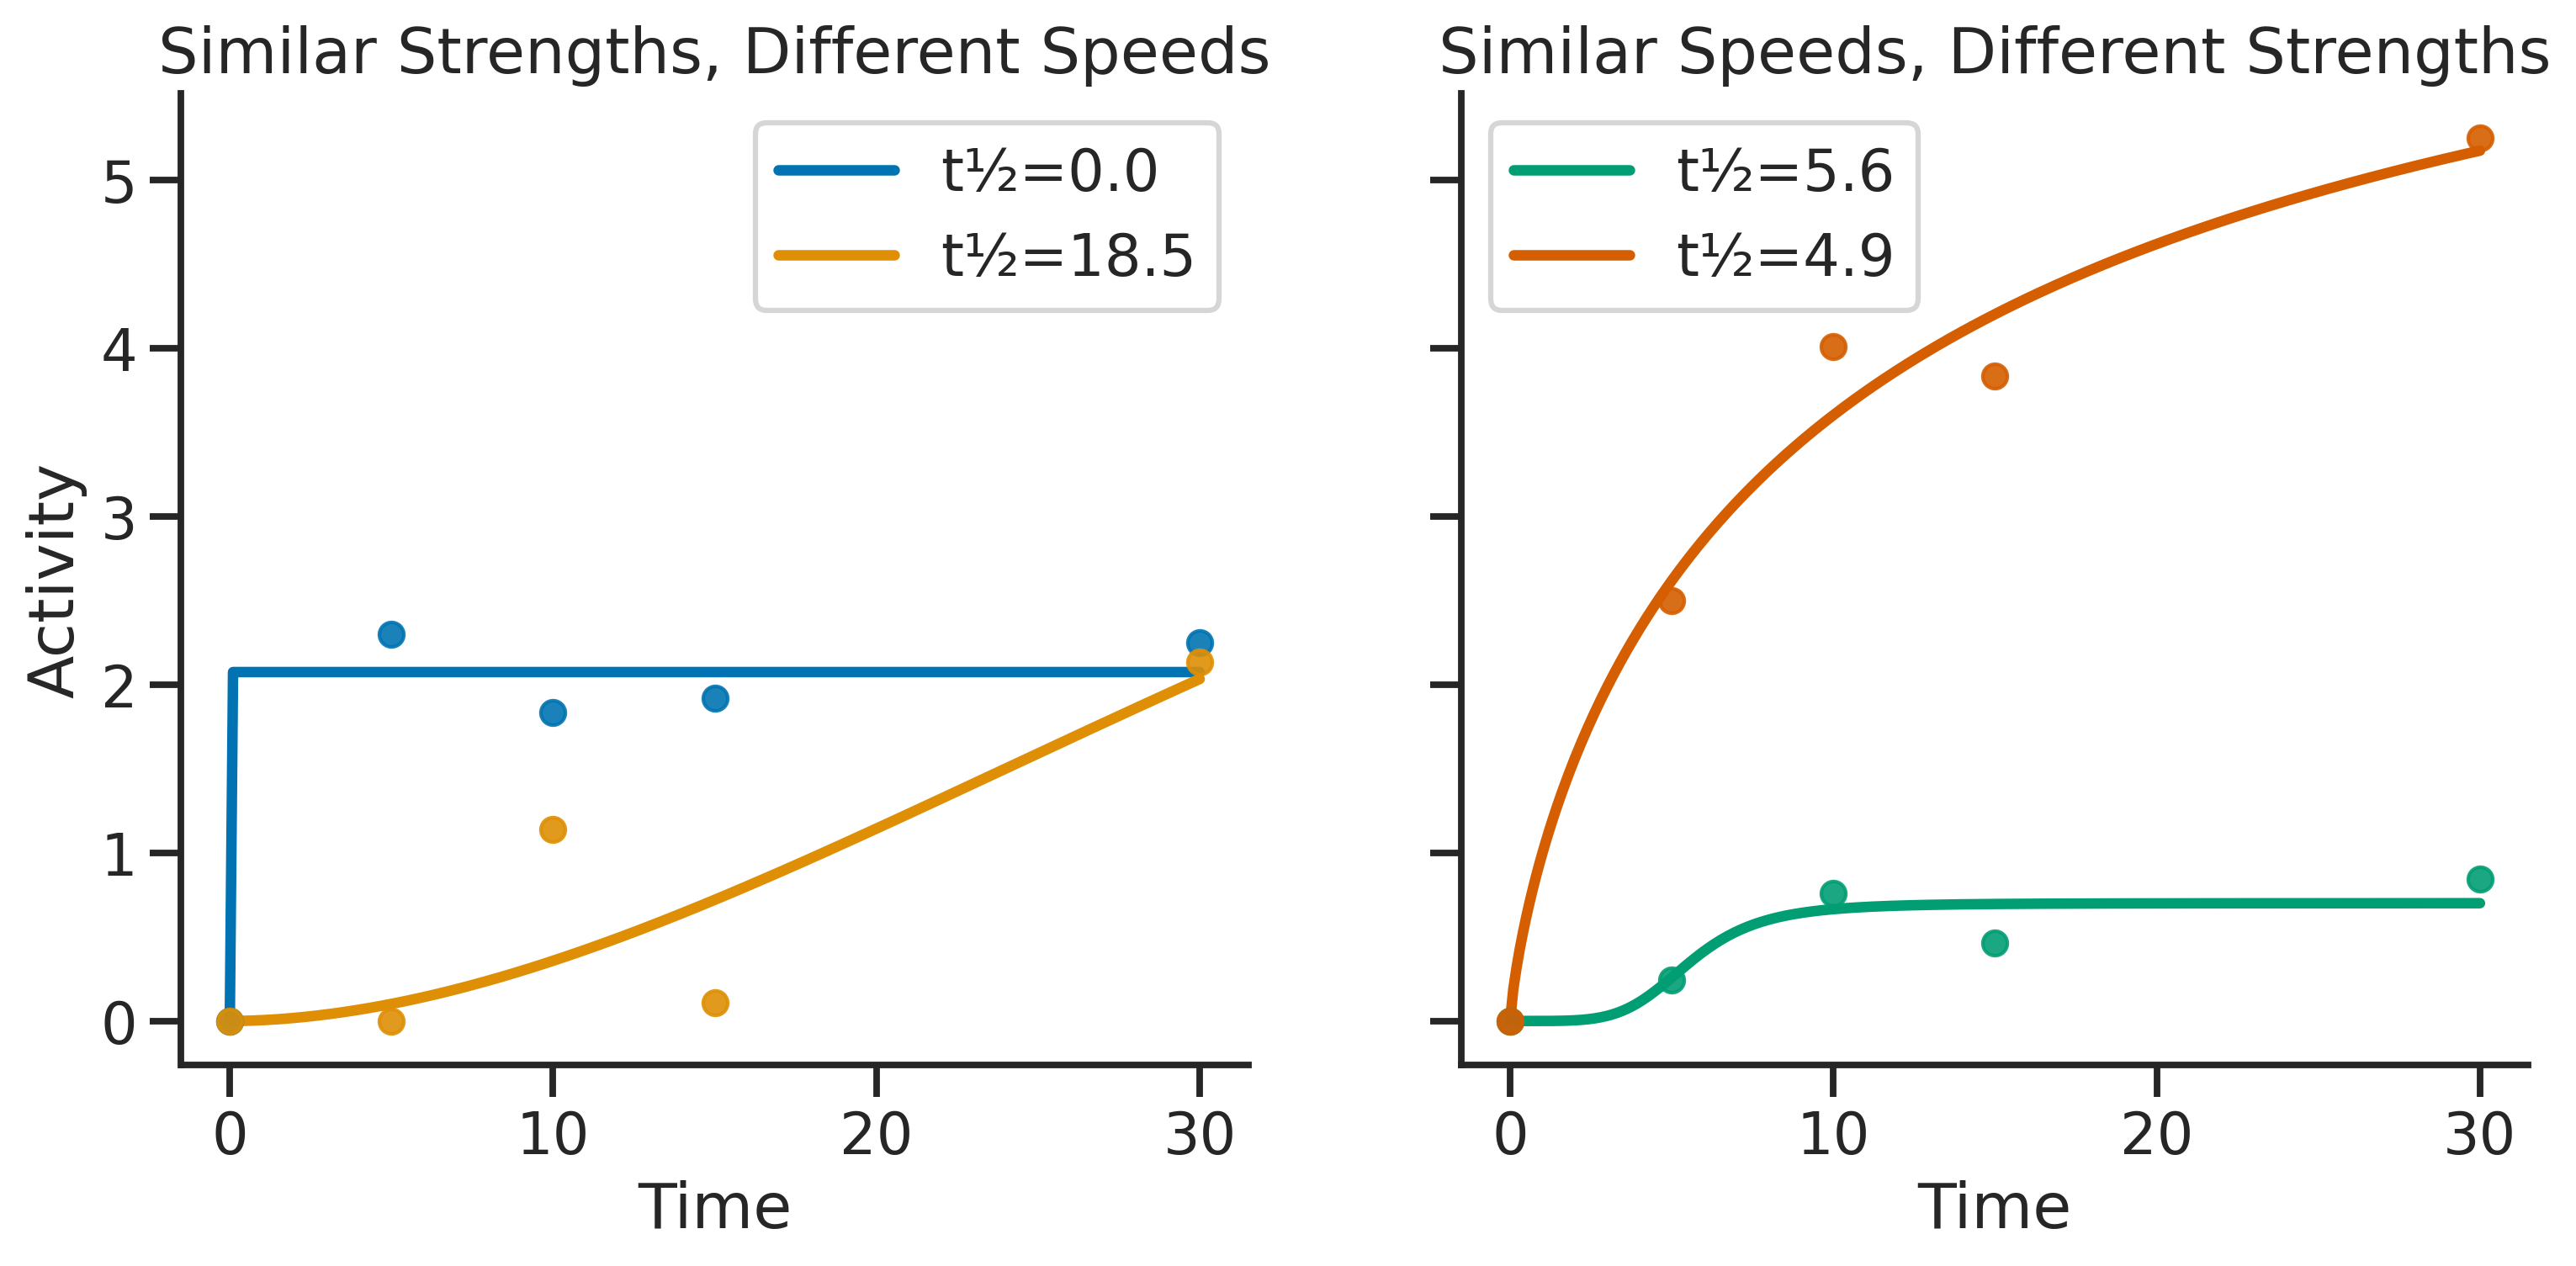

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('talk')

# --- Hill function ---
def hill(t, Vmax, K, n):
    return Vmax * (t**n) / (K**n + t**n)

t_fine = np.linspace(0, activities['time'].max(), 300)
colors = sns.color_palette('colorblind', n_colors=4)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, dpi=300)

# -----------------------------
# Similar Strength, Different Speeds
# -----------------------------
for idx in [0, 1]:

    row = to_plot.iloc[idx]

    grp = activities[activities['ADseq'] == row['ADseq']].sort_values('time')
    t = grp['time'].values
    y = grp['activity_norm'].values

    # --- asymmetric CI error bars ---
    lower_err = y - grp['ci_low_norm'].values
    upper_err = grp['ci_hi_norm'].values - y

    lower_err = np.maximum(0, lower_err)
    upper_err = np.maximum(0, upper_err)

    axs[0].errorbar(
        t, y,
        yerr=[lower_err, upper_err],
        fmt='o',
        color=colors[idx],
        ecolor=colors[idx],
        elinewidth=1.5,
        capsize=2,
        markersize=7,
        alpha=0.9
    )

    if row['success'] and np.isfinite(row['Vmax']):
        axs[0].plot(
            t_fine,
            hill(t_fine, row['Vmax'], row['K_fit'], row['n']),
            color=colors[idx],
            linewidth=3,
            label=f"t½={row['t_half_obs']:.1f}"
        )

axs[0].set_xlabel('Time')
axs[0].set_ylabel('Activity')
axs[0].set_title("Similar Strengths, Different Speeds")
axs[0].legend()
sns.despine(ax=axs[0])

# -----------------------------
# Similar Speed, Different Strengths
# -----------------------------
for idx in [2, 3]:

    row = to_plot.iloc[idx]

    grp = activities[activities['ADseq'] == row['ADseq']].sort_values('time')
    t = grp['time'].values
    y = grp['activity_norm'].values

    # --- asymmetric CI error bars ---
    lower_err = y - grp['ci_low_norm'].values
    upper_err = grp['ci_hi_norm'].values - y

    lower_err = np.maximum(0, lower_err)
    upper_err = np.maximum(0, upper_err)

    axs[1].errorbar(
        t, y,
        yerr=[lower_err, upper_err],
        fmt='o',
        color=colors[idx],
        ecolor=colors[idx],
        elinewidth=1.5,
        capsize=2,
        markersize=7,
        alpha=0.9
    )

    if row['success'] and np.isfinite(row['Vmax']):
        axs[1].plot(
            t_fine,
            hill(t_fine, row['Vmax'], row['K_fit'], row['n']),
            color=colors[idx],
            linewidth=3,
            label=f"t½={row['t_half_obs']:.1f}"
        )

axs[1].set_xlabel('Time')
axs[1].set_title("Similar Speeds, Different Strengths")
axs[1].legend()
sns.despine(ax=axs[1])

# -----------------------------
# shared y-axis scaling
# -----------------------------
grps = activities[activities['ADseq'].isin(to_plot['ADseq'])]

y_min = (grps['activity_norm'] - (grps['ci_hi'] - grps['activity_norm'])).min()

for ax in axs:
    ax.set_ylim(bottom=y_min)

plt.suptitle("GCN4: Hill Fit", y=0.912)
plt.tight_layout()
plt.show()

# 